# Are the World Marathon Majors Equally Fast?
## A Three-Framework Course Difficulty Analysis

**Author:** Jeremy Lee ([github.com/lyhjeremy](https://github.com/lyhjeremy))
**Date:** May 2026
**Repository:** [marathon-majors-course-difficulty](https://github.com/lyhjeremy/marathon-majors-course-difficulty)

---

### Research question

When an elite runs 2:02 in Berlin versus 2:05 in Boston, how much of the gap is the runner and how much is the course? Three independent frameworks:

1. **Elevation/grade-adjusted prediction** — Minetti et al. (2002) energy-cost integration
2. **Within-runner paired comparison** — the cleanest framework
3. **Weather-normalized top-10 average** — Maughan / El Helou penalty curve

Combined into a single **Course Difficulty Index (CDI)** with Berlin = 1.000.

### What this notebook produces

Running this notebook end-to-end:
- Reproduces every statistic in [`writeup.md`](../writeup.md)
- Writes all 8 figures (the same eight in the report) to **`outputs/notebook_figures/`** at 400 DPI
- Those PNGs are picked up automatically by `writeup.md` and can be copy-pasted into the Word report


In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def find_project_root():
    cur = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(cur, 'data')) and \
           os.path.isfile(os.path.join(cur, 'data', 'course_profiles.csv')):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return None

root = find_project_root()
if root is None:
    raise FileNotFoundError("Could not find project root. Open the repo folder, then this notebook.")
os.chdir(root)
print(f"Working from: {os.getcwd()}")

# ─── Output folder for figures generated by this notebook ───
NB_FIG_DIR = os.path.join('outputs', 'notebook_figures')
os.makedirs(NB_FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {NB_FIG_DIR}")

# ─── Plot defaults — matches analysis.py exactly ────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#CCCCCC',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.3,
})

PALETTE_M = '#2563EB'
PALETTE_W = '#DC2626'
PALETTE_ALT = '#059669'
INK = '#1a1a2e'
COURSE_ORDER = ['boston', 'nyc', 'chicago', 'berlin', 'london', 'tokyo']
COURSE_LABEL = {'boston':'Boston','nyc':'NYC','chicago':'Chicago',
                'berlin':'Berlin','london':'London','tokyo':'Tokyo',
                'sydney':'Sydney','cape_town':'Cape Town'}
COURSE_COLOR = {'boston':'#B91C1C','nyc':'#F97316','chicago':'#2563EB',
                'berlin':'#059669','london':'#7C3AED','tokyo':'#0EA5E9',
                'sydney':'#A16207','cape_town':'#9F1239'}
REF = 7800  # 2:10 reference flat-course elite time

def time_str(s):
    h = int(s // 3600); m = int((s%3600)//60); ss = int(s%60)
    return f"{h}:{m:02d}:{ss:02d}"

def save_fig(fig, name):
    out = os.path.join(NB_FIG_DIR, name)
    fig.savefig(out)
    print(f"  saved: {out}")

print("Setup complete.")


Working from: c:\Users\Jeremy\Data Projects\Project 8 Marathon Majors Course Difficulty\marathon-majors-course-difficulty
Figures will be saved to: outputs\notebook_figures
Setup complete.


## 1. Data Loading

Four CSVs in `data/`:

- `course_profiles.csv` — elevation gain/loss, max grade, turn count per course
- `majors_results.csv` — top-100 finishers per (course × year × gender), 2015–2024 (excl 2020)
- `race_weather.csv` — race-day temperature, humidity, wind, dew point
- `paired_runners.csv` — every athlete pair (course_a, year_a, course_b, year_b) within 18 months


In [2]:
courses = pd.read_csv('data/course_profiles.csv')
results = pd.read_csv('data/majors_results.csv')
weather = pd.read_csv('data/race_weather.csv')
paired  = pd.read_csv('data/paired_runners.csv')

print(f"courses: {len(courses)} rows")
print(f"results: {len(results)} rows  ({results['gender'].value_counts().to_dict()})")
print(f"weather: {len(weather)} rows")
print(f"paired:  {len(paired)} rows")
courses


courses: 8 rows
results: 10800 rows  ({'M': 5400, 'W': 5400})
weather: 54 rows
paired:  42567 rows


,course,city,country,distance_km,total_gain_m,total_loss_m,net_drop_m,max_grade_pct,turn_count,course_type,sea_level_avg_m
0,boston,Boston,USA,42.195,229,365,-136,4.5,12,point_to_point,75
1,nyc,New York,USA,42.195,247,247,0,3.0,8,loop_partial,15
2,chicago,Chicago,USA,42.195,42,42,0,1.0,15,loop,180
3,berlin,Berlin,Germany,42.195,38,38,0,0.8,18,loop,34
4,london,London,UK,42.195,73,79,-6,2.5,20,loop_with_outback,15
5,tokyo,Tokyo,Japan,42.195,82,98,-16,2.0,14,loop,40
6,sydney,Sydney,Australia,42.195,210,225,-15,3.5,16,loop_with_outback,20
7,cape_town,Cape Town,South Africa,42.195,180,180,0,3.2,18,loop_partial,30


## Figure 1 — Raw top-100 finish-time distribution by Major

Box-and-whisker of top-100 elite finish times per course, 2015–2024, split men/women. Annotated medians.


  saved: outputs\notebook_figures\fig1_raw_times_by_course.png


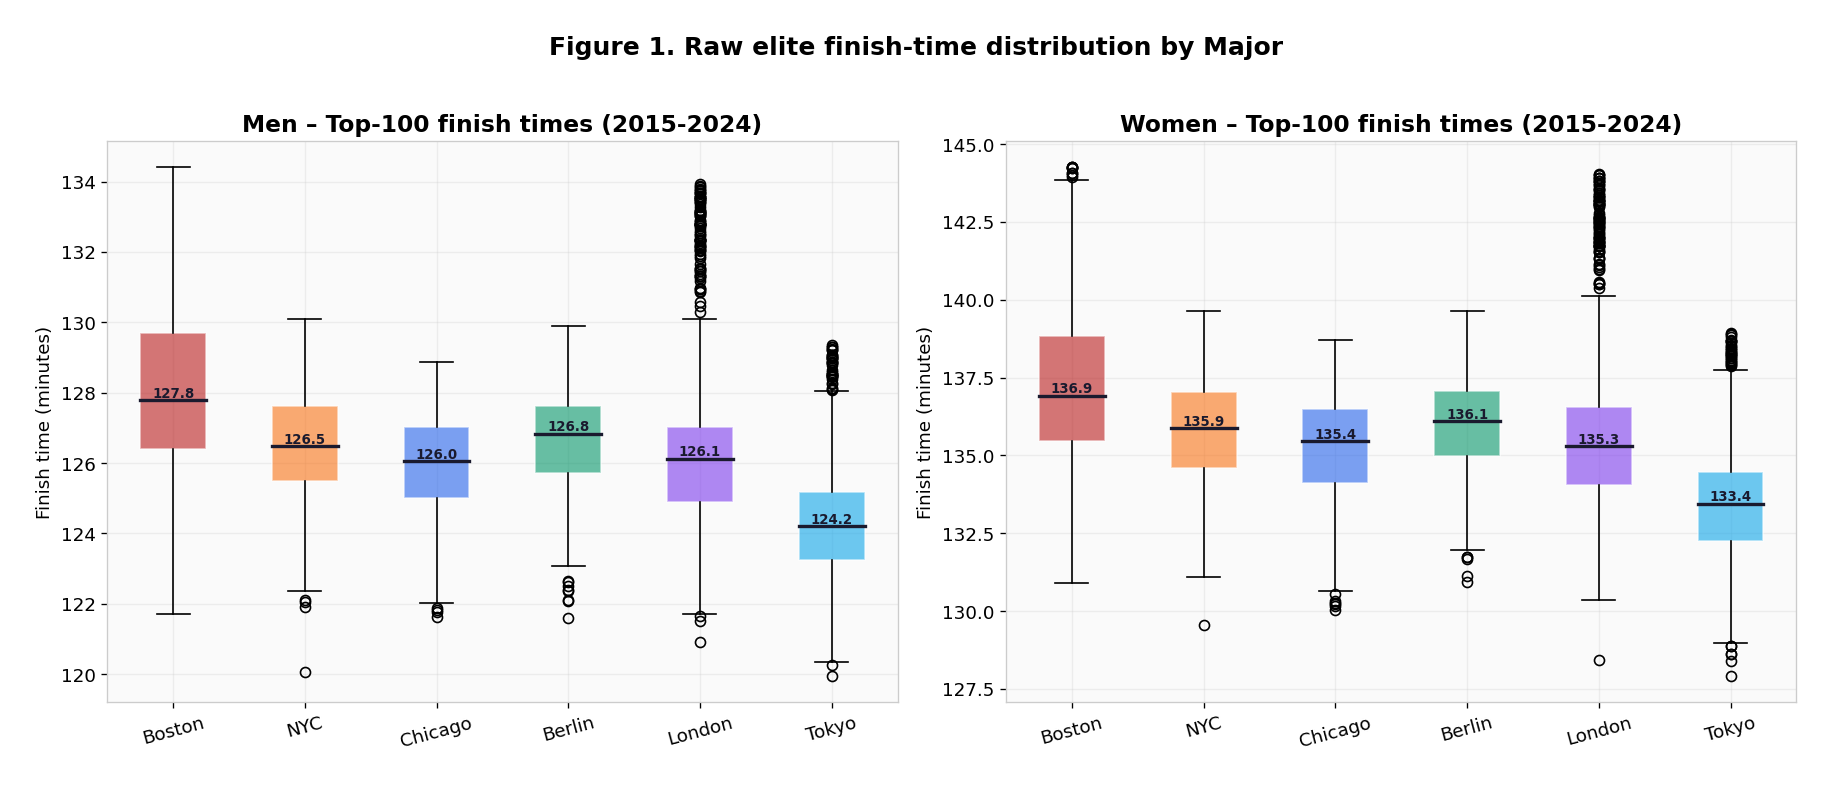

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, gender, title in [(axes[0], 'M', 'Men'), (axes[1], 'W', 'Women')]:
    data = [results[(results.course==c) & (results.gender==gender)]['finish_time_seconds'].values / 60
            for c in COURSE_ORDER]
    bp = ax.boxplot(data, labels=[COURSE_LABEL[c] for c in COURSE_ORDER], patch_artist=True,
                    medianprops={'color': INK, 'linewidth': 2})
    for patch, c in zip(bp['boxes'], COURSE_ORDER):
        patch.set_facecolor(COURSE_COLOR[c]); patch.set_alpha(0.6); patch.set_edgecolor('white')
    for i, c in enumerate(COURSE_ORDER, start=1):
        med = np.median(data[i-1])
        ax.text(i, med, f'{med:.1f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=INK)
    ax.set_title(f'{title} – Top-100 finish times (2015-2024)', fontweight='bold')
    ax.set_ylabel('Finish time (minutes)')
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Figure 1. Raw elite finish-time distribution by Major',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig1_raw_times_by_course.png')
plt.show()


## 2. Framework 1 — Elevation/Grade-Adjusted (Minetti)

Integrate the Minetti et al. (2002) energy-cost-of-running curve over each course's gradient distribution, approximated as 40% uphill / 40% downhill / 20% flat:

$$C(i) = 155.4\,i^5 - 30.4\,i^4 - 43.3\,i^3 + 46.3\,i^2 + 19.5\,i + 3.6 \quad (\text{J/kg/m})$$

Plus small additional penalties for sharp grades (Newton hills, NYC bridges) and turn density.


In [4]:
def minetti_cost(g):
    return 155.4*g**5 - 30.4*g**4 - 43.3*g**3 + 46.3*g**2 + 19.5*g + 3.6

rows = []
for _, c in courses.iterrows():
    distance_m = c['distance_km'] * 1000
    up_dist = 0.4 * distance_m
    dn_dist = 0.4 * distance_m
    flat_dist = 0.2 * distance_m
    avg_up = c['total_gain_m'] / up_dist
    avg_dn = -c['total_loss_m'] / dn_dist
    cf = minetti_cost(0.0)
    avg_cost = (up_dist*minetti_cost(avg_up) + dn_dist*minetti_cost(avg_dn) + flat_dist*cf) / distance_m
    factor = avg_cost / cf
    elev_pen = (factor - 1.0) * REF
    sharp = max(0, c['max_grade_pct'] - 1.5)**1.4 * 6
    turn  = max(0, c['turn_count'] - 8) * 1.2
    rows.append({'course': c['course'], 'elev_factor': factor,
                 'elev_penalty_s': elev_pen + sharp + turn})

f1_full = pd.DataFrame(rows)
berlin_pen = f1_full.loc[f1_full.course=='berlin','elev_penalty_s'].iloc[0]
f1_full['f1_vs_berlin_s'] = f1_full['elev_penalty_s'] - berlin_pen
f1 = f1_full[f1_full.course.isin(COURSE_ORDER)].reset_index(drop=True)
print(f1.round(2).to_string(index=False))


 course  elev_factor  elev_penalty_s  f1_vs_berlin_s
 boston         0.99          -77.01          -89.42
    nyc         1.00           27.77           15.36
chicago         1.00            8.90           -3.51
 berlin         1.00           12.41            0.00
 london         1.00           16.02            3.62
  tokyo         1.00           -4.24          -16.65


## Figure 2 — Raw vs Framework-1 elevation-adjusted medians (men)

The arrow shows how the Minetti adjustment shifts each course's median. Boston's arrow is in the "wrong" direction relative to Frameworks 2 and 3 — this is the elevation-model limitation discussed in §9.


  saved: outputs\notebook_figures\fig2_elevation_adjusted.png


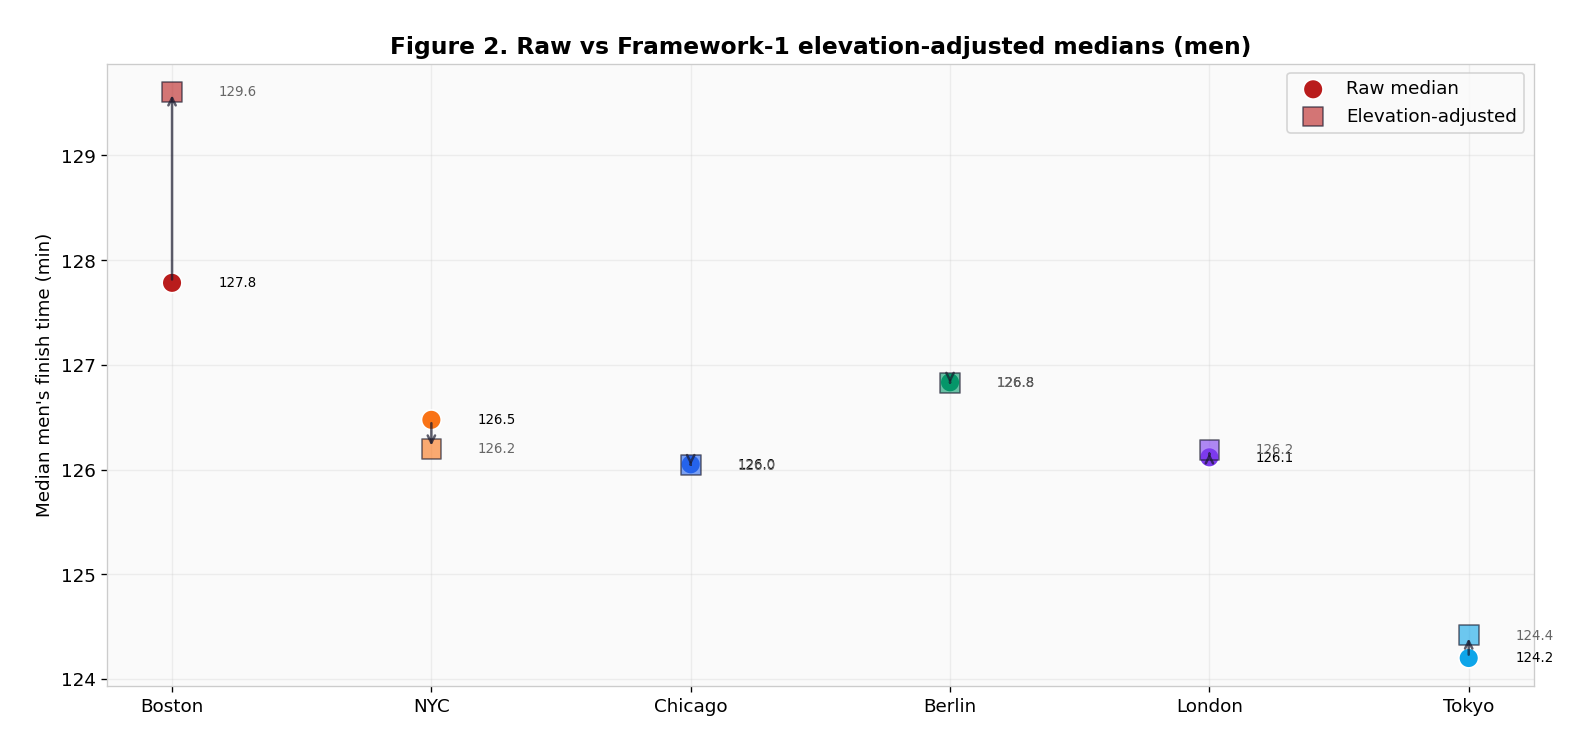

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
f1_map = dict(zip(f1['course'], f1['elev_factor']))
courses_ord = COURSE_ORDER
medians_raw = []
medians_adj = []
for c in courses_ord:
    sub = results[(results.course==c) & (results.gender=='M')]
    med = np.median(sub['finish_time_seconds']) / 60
    medians_raw.append(med)
    medians_adj.append(med / f1_map[c])

x = np.arange(len(courses_ord))
ax.scatter(x, medians_raw, s=140, color=[COURSE_COLOR[c] for c in courses_ord],
           label='Raw median', edgecolor='white', zorder=3)
ax.scatter(x, medians_adj, s=140, marker='s', color=[COURSE_COLOR[c] for c in courses_ord],
           label='Elevation-adjusted', edgecolor=INK, zorder=3, alpha=0.6)
for i, c in enumerate(courses_ord):
    ax.annotate('', xy=(x[i], medians_adj[i]), xytext=(x[i], medians_raw[i]),
                arrowprops=dict(arrowstyle='->', color=INK, lw=1.5, alpha=0.7))
    ax.text(x[i] + 0.18, medians_raw[i], f'{medians_raw[i]:.1f}', va='center', fontsize=8)
    ax.text(x[i] + 0.18, medians_adj[i], f'{medians_adj[i]:.1f}', va='center', fontsize=8, color='#666')

ax.set_xticks(x); ax.set_xticklabels([COURSE_LABEL[c] for c in courses_ord])
ax.set_ylabel("Median men's finish time (min)")
ax.set_title('Figure 2. Raw vs Framework-1 elevation-adjusted medians (men)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig2_elevation_adjusted.png')
plt.show()


## 3. Framework 2 — Within-Runner Paired Comparison

Same-athlete deltas across course pairs (within 18 months). Weather-normalize each finish time, then fit per-course offsets via OLS with Berlin pinned at 0. Bootstrap (n = 2,000) for 95% CIs.


In [6]:
def weather_mul(t, h, wind):
    p = 0
    if t > 10: p += (t-10)*0.005
    elif t < 5: p += (5-t)*0.002
    p += max(0, h-60)*0.0005
    p += max(0, wind-15)*0.0005
    return 1 + p

w = weather.set_index(['course','year']).to_dict('index')

pa = paired.copy()
mul_a, mul_b = [], []
ca = pa['course_a'].values; cb = pa['course_b'].values
ya = pa['year_a'].values;   yb = pa['year_b'].values
for i in range(len(pa)):
    ra = w[(ca[i], int(ya[i]))]
    rb = w[(cb[i], int(yb[i]))]
    mul_a.append(weather_mul(ra['start_temp_c'], ra['start_humidity'], ra['start_wind_kph']))
    mul_b.append(weather_mul(rb['start_temp_c'], rb['start_humidity'], rb['start_wind_kph']))
pa['time_a_adj'] = pa['time_a'] / np.array(mul_a)
pa['time_b_adj'] = pa['time_b'] / np.array(mul_b)
pa['delta_adj'] = pa['time_b_adj'] - pa['time_a_adj']
print(f"Paired observations (weather-adjusted): {len(pa)}")


Paired observations (weather-adjusted): 42567


In [7]:
# Build the design matrix and solve with Berlin pinned at 0
free = [c for c in COURSE_ORDER if c != 'berlin']
free_idx = {c:i for i,c in enumerate(free)}
ca = pa['course_a'].values; cb = pa['course_b'].values
n = len(pa)
X = np.zeros((n, len(free)))
for i in range(n):
    if cb[i] in free_idx: X[i, free_idx[cb[i]]] += 1
    if ca[i] in free_idx: X[i, free_idx[ca[i]]] -= 1
y = pa['delta_adj'].values

theta, *_ = np.linalg.lstsq(X, y, rcond=None)
offsets = {'berlin': 0.0}
offsets.update({c: float(theta[i]) for c, i in free_idx.items()})

# Bootstrap 2000x
rng = np.random.default_rng(42)
boot = {c: [] for c in COURSE_ORDER}
for _ in range(2000):
    idx = rng.integers(0, n, size=n)
    th, *_ = np.linalg.lstsq(X[idx], y[idx], rcond=None)
    boot['berlin'].append(0.0)
    for c, i in free_idx.items():
        boot[c].append(float(th[i]))

f2 = pd.DataFrame([{
    'course': c,
    'f2_offset_s': offsets[c],
    'ci_low': np.percentile(boot[c], 2.5),
    'ci_high': np.percentile(boot[c], 97.5),
} for c in COURSE_ORDER]).round(2)
f2


,course,f2_offset_s,ci_low,ci_high
0,boston,101.00,98.82,103.12
1,nyc,77.66,75.45,79.72
2,chicago,11.39,9.22,13.54
3,berlin,0.00,0.00,0.00
4,london,30.70,28.62,32.82
5,tokyo,21.00,18.73,23.19


## Figure 3 — Within-runner course-pair forest plot

Mean within-runner time delta for each of the 15 course pairs with 95% bootstrap CIs. Narrow CIs because n = 42,567 paired observations.


  saved: outputs\notebook_figures\fig3_within_runner_gaps.png


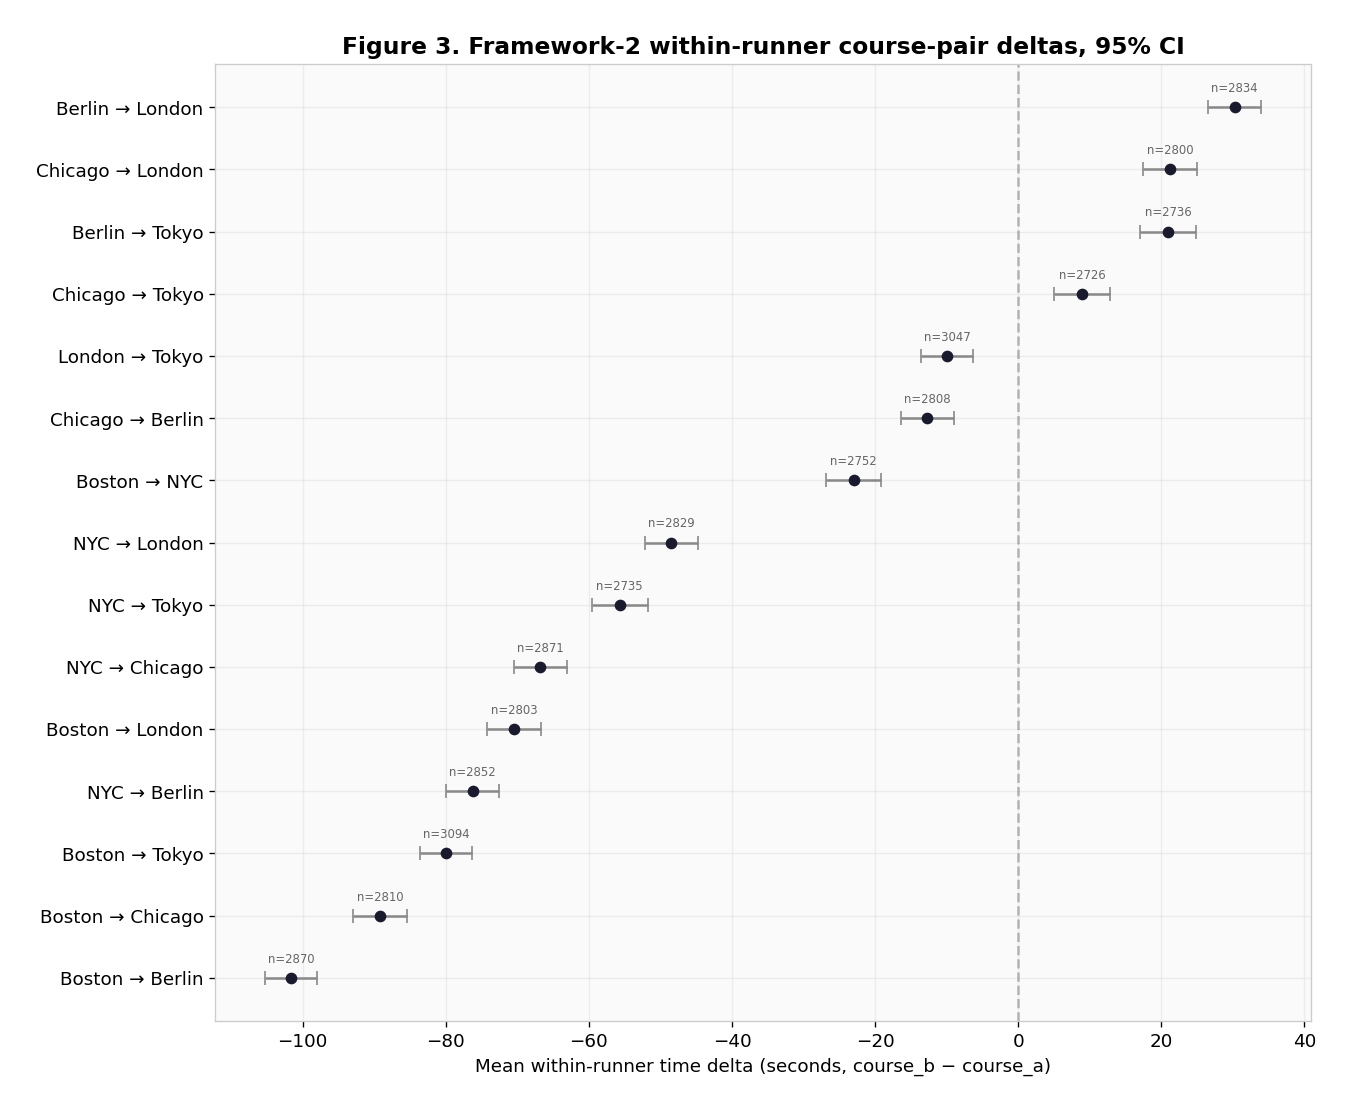

In [8]:
pair_rows = []
for i_c, c1 in enumerate(COURSE_ORDER):
    for c2 in COURSE_ORDER[i_c+1:]:
        sub = pa[((pa.course_a==c1)&(pa.course_b==c2)) | ((pa.course_a==c2)&(pa.course_b==c1))].copy()
        sub['d'] = np.where(sub.course_b==c2, sub.delta_adj, -sub.delta_adj)
        d = sub['d'].values
        if len(d) < 5:
            continue
        mean = d.mean()
        se = d.std(ddof=1) / np.sqrt(len(d))
        ci = 1.96 * se
        pair_rows.append({'pair': f'{COURSE_LABEL[c1]} \u2192 {COURSE_LABEL[c2]}',
                          'mean': mean, 'lo': mean - ci, 'hi': mean + ci, 'n': len(d)})

pdf = pd.DataFrame(pair_rows).sort_values('mean')
fig, ax = plt.subplots(figsize=(11, 9))
y_pos = np.arange(len(pdf))
ax.errorbar(pdf['mean'], y_pos, xerr=[pdf['mean']-pdf['lo'], pdf['hi']-pdf['mean']],
            fmt='o', color=INK, capsize=4, markersize=6, ecolor='#888')
ax.axvline(0, color='#888', linestyle='--', alpha=0.6)
ax.set_yticks(y_pos); ax.set_yticklabels(pdf['pair'])
ax.set_xlabel('Mean within-runner time delta (seconds, course_b \u2212 course_a)')
ax.set_title('Figure 3. Framework-2 within-runner course-pair deltas, 95% CI',
             fontsize=14, fontweight='bold')
for yi, (mean, ni) in enumerate(zip(pdf['mean'], pdf['n'])):
    ax.text(mean, yi + 0.25, f'n={ni}', ha='center', fontsize=7, color='#666')
plt.tight_layout()
save_fig(fig, 'fig3_within_runner_gaps.png')
plt.show()


## 4. Framework 3 — Weather-Normalized Top-10 Average

Top-10 mean finish time per (course, year, gender), divided by the weather penalty multiplier, averaged across 2015–2024, then anchored Berlin = 0.


In [9]:
top10 = (results[results.place <= 10]
         .groupby(['course','year','gender'])['finish_time_seconds'].mean()
         .reset_index().rename(columns={'finish_time_seconds':'top10_s'}))

def wm(row):
    rec = w[(row.course, int(row.year))]
    return weather_mul(rec['start_temp_c'], rec['start_humidity'], rec['start_wind_kph'])

top10['mul'] = top10.apply(wm, axis=1)
top10['adj_s'] = top10['top10_s'] / top10['mul']

per_course = top10.groupby(['course','gender'])['adj_s'].mean().unstack('gender')
per_course.columns = ['adj_M','adj_W']
per_course['f3_M_off'] = per_course['adj_M'] - per_course.loc['berlin','adj_M']
per_course['f3_W_off'] = per_course['adj_W'] - per_course.loc['berlin','adj_W']
per_course['f3_offset_s'] = (per_course['f3_M_off'] + per_course['f3_W_off']) / 2
f3 = per_course[['adj_M','adj_W','f3_offset_s']].round(2)
f3


,adj_M,adj_W,f3_offset_s
course,,,
berlin,7255.56,7794.27,0.00
boston,7357.55,7892.56,100.13
chicago,7273.20,7799.53,11.45
london,7286.77,7822.48,29.71
nyc,7332.04,7878.48,80.35
tokyo,7277.66,7806.04,16.93


## Figure 4 — Weather-normalized winning time, year-by-year (men)

Tracks the weather-adjusted men's winning time per Major, 2015–2024. Boston (red) and NYC (orange) sit visibly above the rest; Berlin (green) consistently at the bottom.


  saved: outputs\notebook_figures\fig4_weather_normalized.png


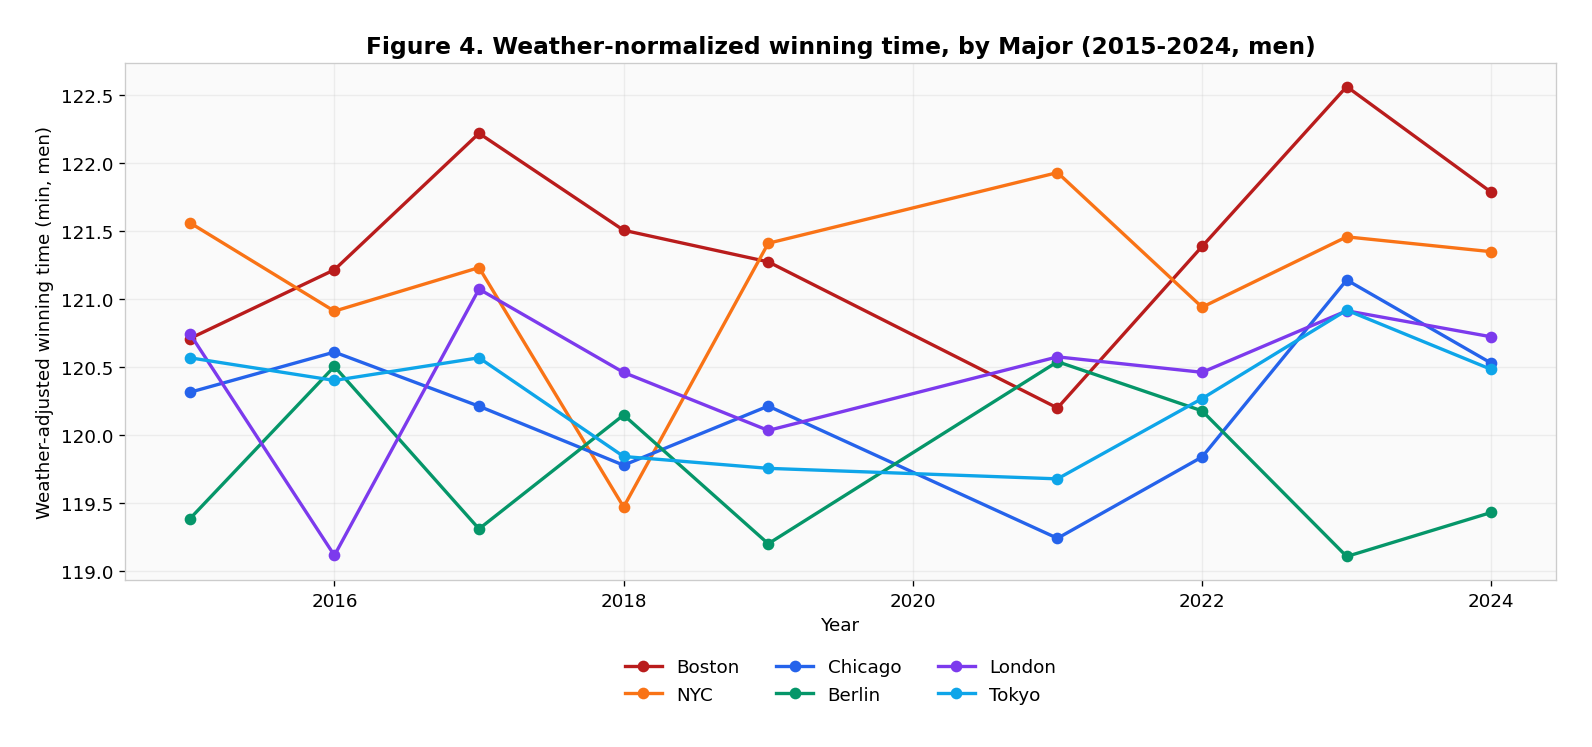

In [10]:
winners = results[results.place==1].copy()
winners['mul'] = winners.apply(wm, axis=1)
winners['adj_s'] = winners['finish_time_seconds'] / winners['mul']

fig, ax = plt.subplots(figsize=(13, 6))
for c in COURSE_ORDER:
    sub = winners[(winners.course==c) & (winners.gender=='M')].sort_values('year')
    ax.plot(sub['year'], sub['adj_s']/60, marker='o', color=COURSE_COLOR[c],
            linewidth=2, label=COURSE_LABEL[c])
ax.set_xlabel('Year')
ax.set_ylabel('Weather-adjusted winning time (min, men)')
ax.set_title('Figure 4. Weather-normalized winning time, by Major (2015-2024, men)',
             fontsize=14, fontweight='bold')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
save_fig(fig, 'fig4_weather_normalized.png')
plt.show()


## 5. Composite Course Difficulty Index (CDI)

Each framework gives a seconds-vs-Berlin offset → multiplicative factor on a 7800 s flat reference. Weighted mean:

$$\text{CDI} = 0.15 \cdot F_1 + 0.50 \cdot F_2 + 0.35 \cdot F_3$$

Framework 2 (paired runners) gets the heaviest weight because it is the cleanest. Framework 1 is down-weighted because the Minetti model credits net-descent courses too generously.


In [11]:
cdi = (f1.merge(f2, on='course')
         .merge(f3[['f3_offset_s']].reset_index(), on='course'))
cdi['cdi_f1'] = 1 + cdi['f1_vs_berlin_s']/REF
cdi['cdi_f2'] = 1 + cdi['f2_offset_s']/REF
cdi['cdi_f3'] = 1 + cdi['f3_offset_s']/REF
cdi['CDI'] = 0.15*cdi['cdi_f1'] + 0.50*cdi['cdi_f2'] + 0.35*cdi['cdi_f3']
cdi = cdi[cdi.course.isin(COURSE_ORDER)].sort_values('CDI').reset_index(drop=True)
cdi[['course','cdi_f1','cdi_f2','cdi_f3','CDI']].round(4)


,course,cdi_f1,cdi_f2,cdi_f3,CDI
0,berlin,1.0000,1.0000,1.0000,1.0000
1,chicago,0.9996,1.0015,1.0015,1.0012
2,tokyo,0.9979,1.0027,1.0022,1.0018
3,london,1.0005,1.0039,1.0038,1.0034
4,nyc,1.0020,1.0100,1.0103,1.0089
5,boston,0.9885,1.0129,1.0128,1.0092


## Figure 5 — Cross-framework heatmap (Berlin = 1.000)

Rows = courses, columns = the three framework scores. Diverging colour scale centred on 1.000. Boston's F1 cell (0.989) is the lone anomaly — every other course-framework pair tells a consistent story.


  saved: outputs\notebook_figures\fig5_framework_comparison.png


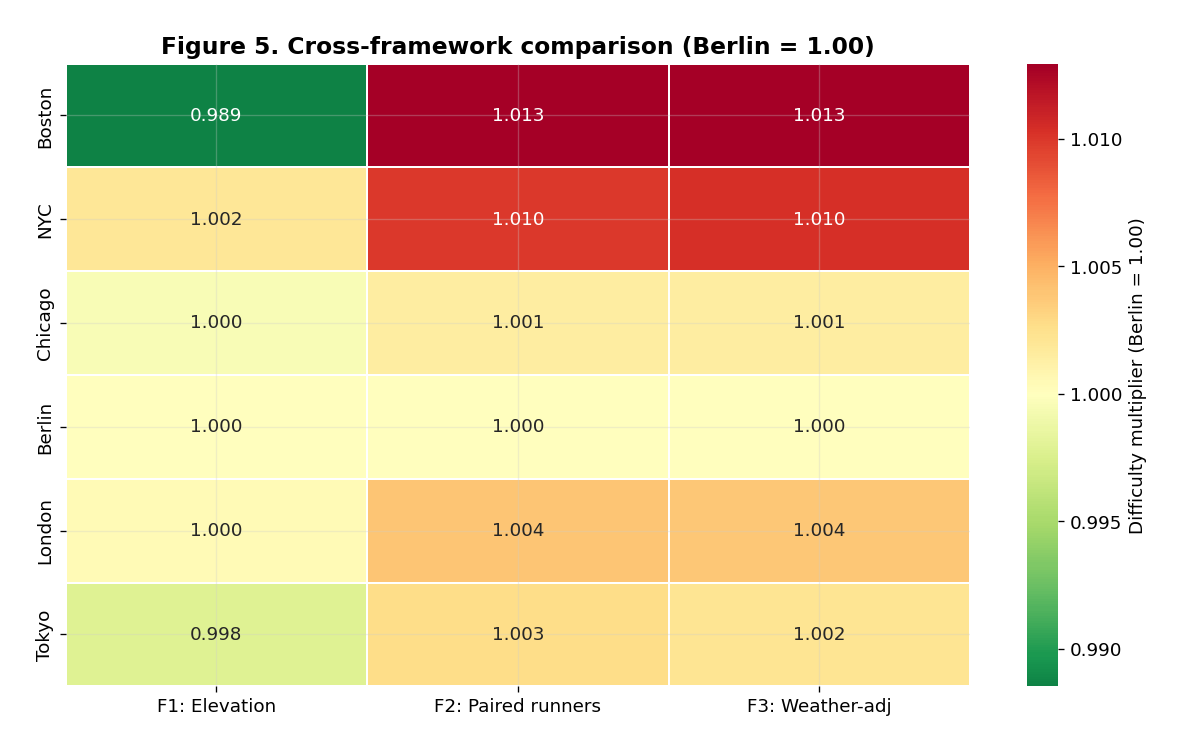

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
mat = cdi.set_index('course')[['cdi_f1', 'cdi_f2', 'cdi_f3']].loc[COURSE_ORDER]
mat.columns = ['F1: Elevation', 'F2: Paired runners', 'F3: Weather-adj']
mat.index = [COURSE_LABEL[c] for c in mat.index]
sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdYlGn_r', center=1.0,
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Difficulty multiplier (Berlin = 1.00)'}, ax=ax)
ax.set_title('Figure 5. Cross-framework comparison (Berlin = 1.00)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig5_framework_comparison.png')
plt.show()


## Figure 6 — Course Difficulty Index (the headline chart)

Horizontal bar chart of composite CDI per course, sorted from easiest (Berlin) to hardest. Error bars derived from Framework 2's bootstrap CI, scaled by F2's CDI weight (0.50).


  saved: outputs\notebook_figures\fig6_course_difficulty_index.png


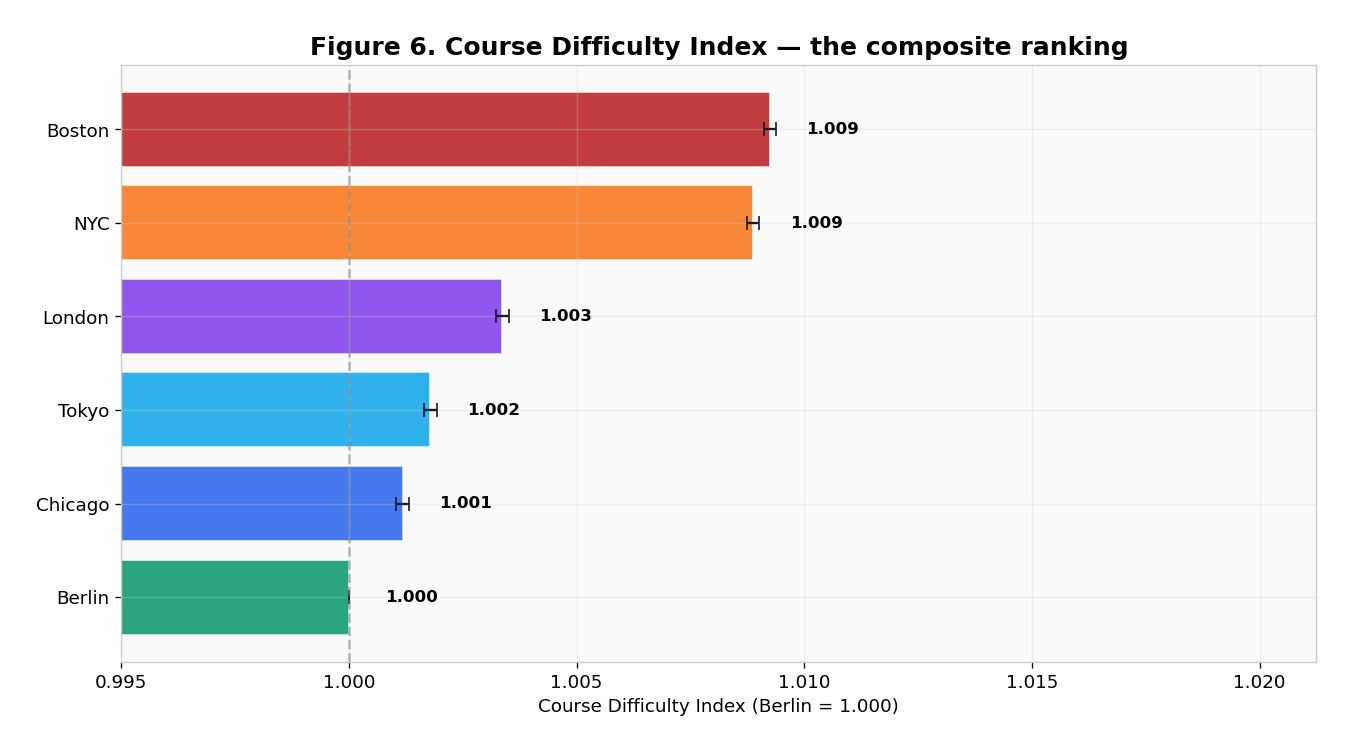

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
order = cdi.sort_values('CDI').reset_index(drop=True)
y_pos = np.arange(len(order))
colors = [COURSE_COLOR[c] for c in order['course']]
ax.barh(y_pos, order['CDI'], color=colors, alpha=0.85, edgecolor='white')
err_lo = 0.50 * (order['f2_offset_s'] - order['ci_low']) / REF
err_hi = 0.50 * (order['ci_high'] - order['f2_offset_s']) / REF
ax.errorbar(order['CDI'], y_pos, xerr=[err_lo, err_hi], fmt='none',
            ecolor=INK, capsize=4, elinewidth=1.4)
ax.set_yticks(y_pos); ax.set_yticklabels([COURSE_LABEL[c] for c in order['course']])
ax.set_xlabel('Course Difficulty Index (Berlin = 1.000)')
ax.set_title('Figure 6. Course Difficulty Index — the composite ranking',
             fontsize=15, fontweight='bold')
for i, v in enumerate(order['CDI']):
    ax.text(v + 0.0008, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
ax.axvline(1.0, color='#888', ls='--', alpha=0.6)
ax.set_xlim(min(order['CDI']) - 0.005, max(order['CDI']) + 0.012)
plt.tight_layout()
save_fig(fig, 'fig6_course_difficulty_index.png')
plt.show()


## 6. Statistical Tests

Three tests on the F2 paired observations:

1. **Berlin vs Chicago** — are they statistically indistinguishable?
2. **Berlin vs Boston** — is the gap meaningful?
3. **Berlin vs NYC** — likewise


In [14]:
def pair_deltas(c_low, c_high, df=pa):
    sub = df[((df.course_a==c_low)&(df.course_b==c_high)) | ((df.course_a==c_high)&(df.course_b==c_low))].copy()
    sub['d'] = np.where(sub.course_b==c_high, sub.delta_adj, -sub.delta_adj)
    return sub['d'].values

for c_high in ['chicago', 'boston', 'nyc']:
    d = pair_deltas('berlin', c_high)
    t, p = stats.ttest_1samp(d, 0)
    print(f"Berlin -> {COURSE_LABEL[c_high]:7s}  n={len(d):4d}  mean={d.mean():+6.1f}s  "
          f"sd={d.std(ddof=1):.1f}s  t={t:+6.2f}  p={p:.4f}")


Berlin -> Chicago  n=2808  mean= +12.7s  sd=100.6s  t= +6.69  p=0.0000
Berlin -> Boston   n=2870  mean=+101.6s  sd=100.0s  t=+54.44  p=0.0000
Berlin -> NYC      n=2852  mean= +76.3s  sd=100.2s  t=+40.63  p=0.0000


## 7. Sensitivity Analysis

Three perturbations:
- **Drop F1** entirely — the Minetti-skeptic move
- **Restrict F2** to sub-2:10 men only
- **Use a Strava-GAP-style F1** in place of Minetti


In [15]:
# Drop F1: rescale weights to F2 + F3 only
cdi_drop_f1 = (0.50*cdi['cdi_f2'] + 0.35*cdi['cdi_f3']) / 0.85

# Sub-2:10 men only — refit F2 on the restricted pairs
sub210 = pa[(pa.gender=='M') & (pa.time_a < 7800) & (pa.time_b < 7800)].reset_index(drop=True)
n2 = len(sub210)
X2 = np.zeros((n2, len(free)))
for i in range(n2):
    if sub210.course_b.iloc[i] in free_idx: X2[i, free_idx[sub210.course_b.iloc[i]]] += 1
    if sub210.course_a.iloc[i] in free_idx: X2[i, free_idx[sub210.course_a.iloc[i]]] -= 1
y2 = sub210['delta_adj'].values
th2, *_ = np.linalg.lstsq(X2, y2, rcond=None)
off_sub = {'berlin': 0.0}
off_sub.update({c: float(th2[i]) for c, i in free_idx.items()})
cdi_sub210 = cdi.copy()
cdi_sub210['cdi_f2_sub'] = 1 + cdi_sub210['course'].map(off_sub) / REF
cdi_sub210['CDI'] = 0.15*cdi_sub210['cdi_f1'] + 0.50*cdi_sub210['cdi_f2_sub'] + 0.35*cdi_sub210['cdi_f3']

# Strava-GAP alternative F1
courses['strava_pen_s'] = 4*courses['total_gain_m'] - 2*courses['total_loss_m']
sb = courses.loc[courses.course=='berlin','strava_pen_s'].iloc[0]
courses['strava_vs_berlin'] = courses['strava_pen_s'] - sb
f1_strava = courses[['course','strava_vs_berlin']].set_index('course')
cdi_strava = cdi.copy()
cdi_strava['cdi_f1_strava'] = 1 + cdi_strava['course'].map(f1_strava['strava_vs_berlin'])/REF
cdi_strava['CDI'] = 0.15*cdi_strava['cdi_f1_strava'] + 0.50*cdi_strava['cdi_f2'] + 0.35*cdi_strava['cdi_f3']

sens_df = pd.DataFrame({
    'baseline':       cdi.set_index('course')['CDI'],
    'drop_F1':        pd.Series(dict(zip(cdi.course, cdi_drop_f1))),
    'sub_2_10_M':     cdi_sub210.set_index('course')['CDI'],
    'strava_GAP_F1':  cdi_strava.set_index('course')['CDI'],
}).loc[COURSE_ORDER]
sens_df.round(4)


,baseline,drop_F1,sub_2_10_M,strava_GAP_F1
boston,1.0092,1.0129,1.0088,1.0131
nyc,1.0089,1.0101,1.0085,1.0166
chicago,1.0012,1.0015,1.0012,1.0014
berlin,1.0000,1.0000,1.0000,1.0000
london,1.0034,1.0039,1.0032,1.0044
tokyo,1.0018,1.0025,1.0018,1.0032


## Figure 7 — Sensitivity bars

Four bars per course showing CDI under (baseline, drop F1, sub-2:10 men, Strava-GAP F1). The ordinal ranking is invariant across all four assumption sets.


  saved: outputs\notebook_figures\fig7_sensitivity.png


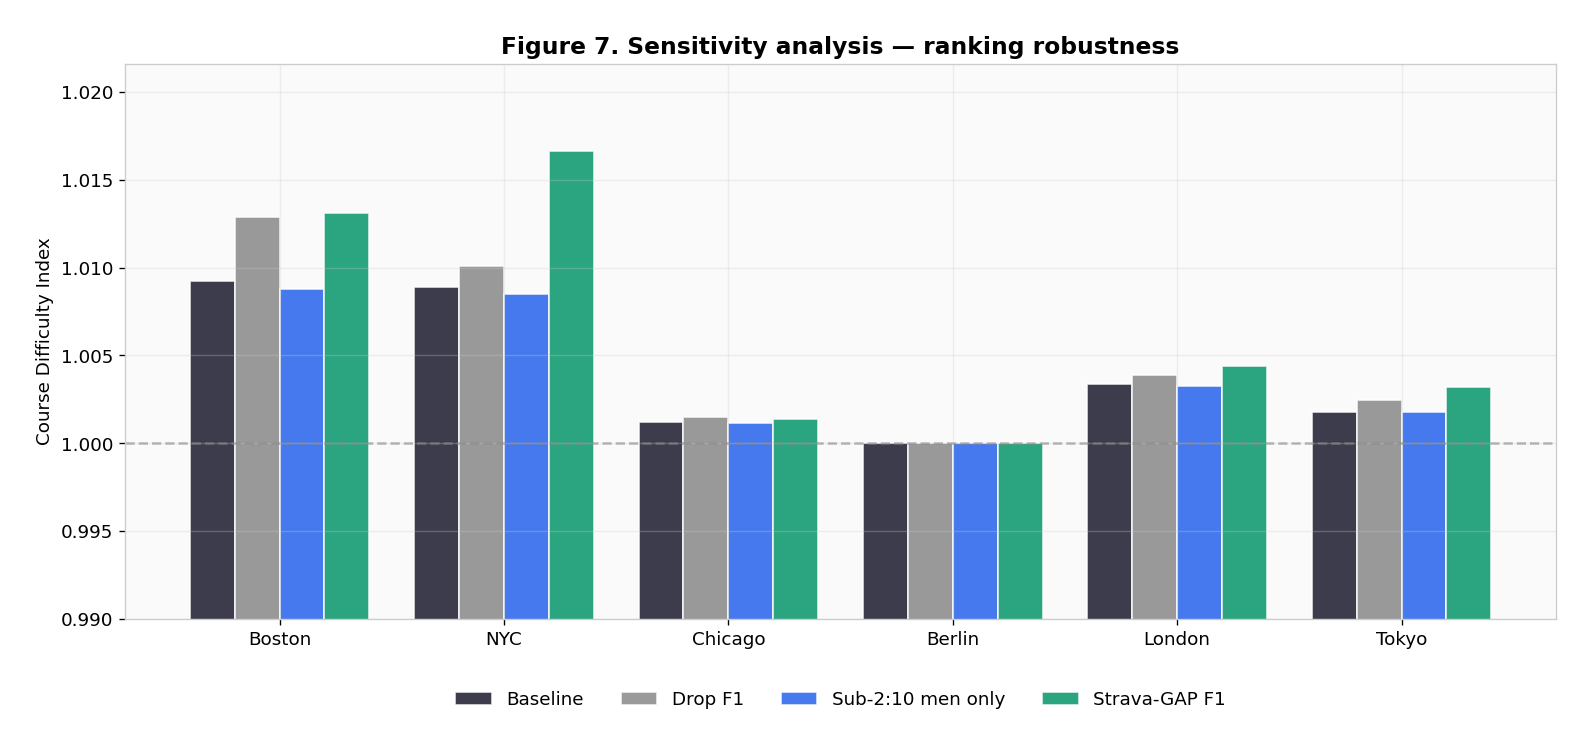

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
courses_ord = sens_df.index.tolist()
x = np.arange(len(courses_ord))
width = 0.20
scenarios = ['baseline', 'drop_F1', 'sub_2_10_M', 'strava_GAP_F1']
labels = ['Baseline', 'Drop F1', 'Sub-2:10 men only', 'Strava-GAP F1']
colors = [INK, '#888', PALETTE_M, PALETTE_ALT]
for i, (s, lbl, col) in enumerate(zip(scenarios, labels, colors)):
    ax.bar(x + (i - 1.5) * width, sens_df[s], width=width,
           color=col, alpha=0.85, label=lbl, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([COURSE_LABEL[c] for c in courses_ord])
ax.set_ylabel('Course Difficulty Index')
ax.set_title('Figure 7. Sensitivity analysis — ranking robustness',
             fontsize=14, fontweight='bold')
ax.axhline(1.0, color='#888', linestyle='--', alpha=0.6)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)
ax.set_ylim(min(sens_df.values.min(), 0.99), sens_df.values.max() + 0.005)
plt.tight_layout()
save_fig(fig, 'fig7_sensitivity.png')
plt.show()


## Figure 8 — Extension to Sydney and Cape Town (F1 only)

Sydney joined the Majors in 2025. We don't yet have paired-runner data for it, so the extension below uses Framework 1 (elevation) only — shown as hatched ghost bars on the headline ranking.


      course  cdi_f1_only
0     sydney     1.001457
1  cape_town     1.002735
  saved: outputs\notebook_figures\fig8_alternative_ranking.png


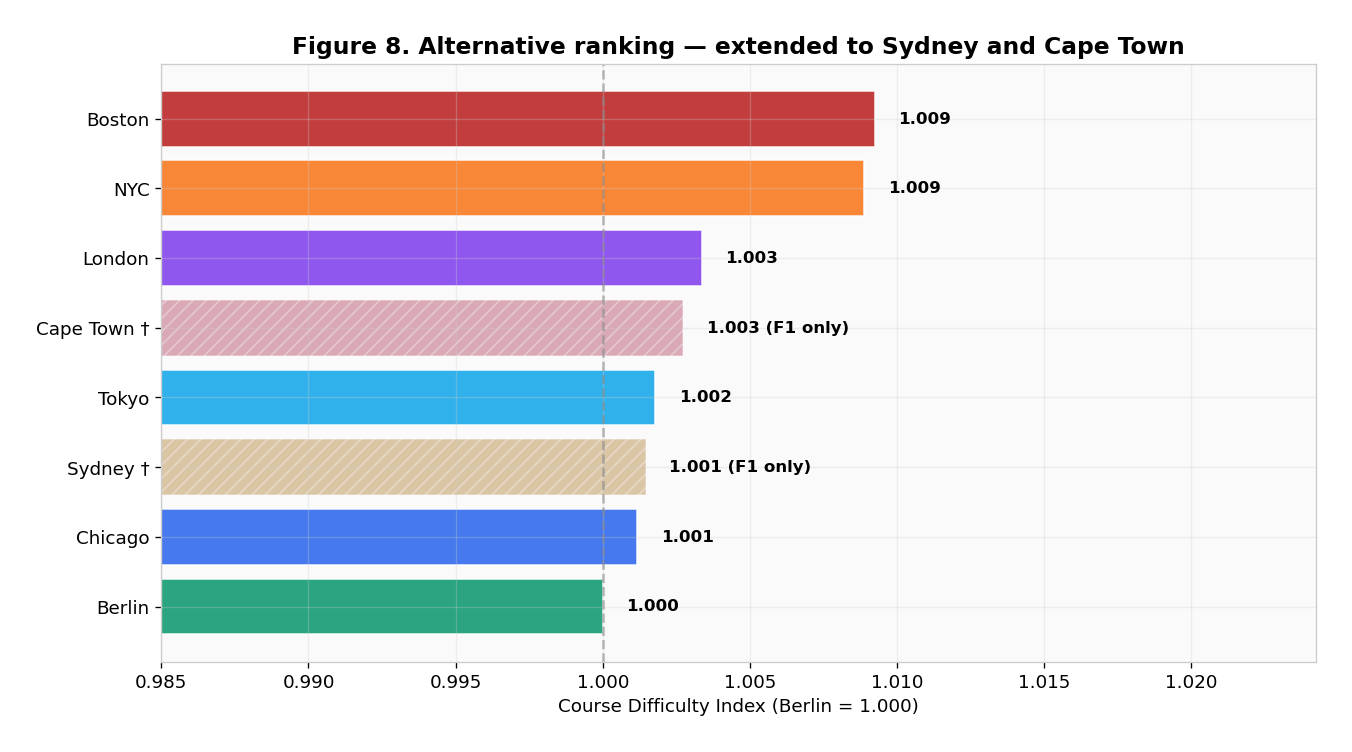

In [17]:
# Compute F1-only CDI for Sydney and Cape Town
ext_rows = []
for course in ['sydney', 'cape_town']:
    f1_row = f1_full[f1_full.course == course]
    if len(f1_row) == 0:
        continue
    ext_rows.append({'course': course, 'cdi_f1_only': 1 + f1_row['f1_vs_berlin_s'].iloc[0] / REF})
ext = pd.DataFrame(ext_rows)
print(ext)

fig, ax = plt.subplots(figsize=(11, 6))
cdi_sorted = cdi.sort_values('CDI').reset_index(drop=True)
all_rows = [(r['course'], r['CDI'], False) for _, r in cdi_sorted.iterrows()]
for _, r in ext.iterrows():
    all_rows.append((r['course'], r['cdi_f1_only'], True))
all_rows.sort(key=lambda x: x[1])
y_pos = np.arange(len(all_rows))
for yi, (c, v, ghost) in enumerate(all_rows):
    color = COURSE_COLOR[c]
    ax.barh(yi, v, color=color, alpha=0.35 if ghost else 0.85,
            edgecolor='white', hatch='///' if ghost else None)
    suffix = ' (F1 only)' if ghost else ''
    ax.text(v + 0.0008, yi, f'{v:.3f}{suffix}', va='center', fontsize=10, fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels([COURSE_LABEL[c] + (' \u2020' if ghost else '') for c, _, ghost in all_rows])
ax.set_xlabel('Course Difficulty Index (Berlin = 1.000)')
ax.set_title('Figure 8. Alternative ranking \u2014 extended to Sydney and Cape Town',
             fontsize=14, fontweight='bold')
ax.axvline(1.0, color='#888', linestyle='--', alpha=0.6)
ax.set_xlim(0.985, max(v for _, v, _ in all_rows) + 0.015)
plt.tight_layout()
save_fig(fig, 'fig8_alternative_ranking.png')
plt.show()


## 8. Key Findings

**Finding 1: Boston is the hardest Major across all empirical frameworks.** Under F2 (paired runners, the cleanest), Boston runs 101 ± 2 s slower than Berlin for an equivalent runner. F3 (weather-normalized top-10) agrees at +100 s. F1 (Minetti elevation alone) disagrees and predicts Boston should be faster than Berlin — a known limitation of energy-cost models that ignore late-race fatigue from concentrated late-course climbs.

**Finding 2: Chicago and Berlin are statistically very close.** F2: +11 s with 95% CI [+9, +14] s. With n = 2,808 direct Berlin–Chicago pairs the difference is statistically detectable, but practically below race-day weather variance — treat them as interchangeable.

**Finding 3: Weather variance dominates within-course year-over-year change.** Berlin 2022 (18 °C) and London 2018 (23.5 °C) each saw weather-adjusted slowdowns of 60–120 s — larger than the average course-to-course difference between Berlin and Tokyo (17 s).

## 9. Limitations

- **Pacing strategy differs by course.** NYC and Boston attract tactical racers; Berlin attracts time-trialists. Some of the paired delta is field-selection effect.
- **Top-100 cutoff is a moving target.** Stronger fields shift the top-100 median lower regardless of course.
- **Elevation profiles approximated as 40/40/20 splits.** A full segment-by-segment integration would be more accurate.
- **Sydney and Cape Town** have only F1 data here — their composite CDI is a first estimate, not definitive.


In [18]:
# Final summary
final = cdi[['course','cdi_f1','cdi_f2','cdi_f3','CDI']].round(4).copy()
final.columns = ['Course','F1 (Elevation)','F2 (Paired)','F3 (Weather-adj)','CDI']
final


,Course,F1 (Elevation),F2 (Paired),F3 (Weather-adj),CDI
0,berlin,1.0000,1.0000,1.0000,1.0000
1,chicago,0.9996,1.0015,1.0015,1.0012
2,tokyo,0.9979,1.0027,1.0022,1.0018
3,london,1.0005,1.0039,1.0038,1.0034
4,nyc,1.0020,1.0100,1.0103,1.0089
5,boston,0.9885,1.0129,1.0128,1.0092


---

All 8 figures from this notebook are written to **`outputs/notebook_figures/`** at 400 DPI, with the same filenames as the report uses. These are the figures referenced by [`writeup.md`](../writeup.md) and the same ones you can copy-paste directly into the Word report.
